## Preprocess the data

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore")

df = pd.read_csv('../EDA/train_dataset_final.csv')

In [2]:
def convert_categorize(df):
    import pandas as pd

    # Define category orders
    sleep_categories = ['< 5 hours', '5-6 hours', '7-8 hours', '> 8 hours']
    habit_categories = ['Unhealthy', 'Moderate', 'Healthy']
    age_categories = ['<20', '20-30', '30-40', '40-50', '> 50']
    age_risk = ['< 30','30+']
    risk_level = ['Low Risk','High Risk']
    financial_order = [1,2,3,4,5]
    work_study_order = [0,1,2,3,4,5]
    work_hour = [i for i in range(13)]

    # Convert columns to ordered categorical types if they exist
    df['Sleep Duration'] = pd.Categorical(df['Sleep Duration'], categories=sleep_categories, ordered=True)
    df['Dietary Habits'] = pd.Categorical(df['Dietary Habits'], categories=habit_categories, ordered=True)
    df['Age_Group'] = df['Age_Group'].str.strip()
    df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=age_categories, ordered=True)
    df['Age_Risk'] = pd.Categorical(df['Age_Risk'],categories=age_risk, ordered=True)
    df['Risk_Level'] = pd.Categorical(df['Risk_Level'], categories=risk_level, ordered=True)
    df['Academic Pressure'] = pd.Categorical(df['Academic Pressure'],categories=work_study_order,ordered=True)
    df['Work Pressure'] = pd.Categorical(df['Work Pressure'], categories=work_study_order,ordered=True)
    df['Study Satisfaction'] = pd.Categorical(df['Study Satisfaction'],categories=work_study_order, ordered=True)
    df['Job Satisfaction'] = pd.Categorical(df['Job Satisfaction'], categories=work_study_order,ordered=True)
    df['Financial Stress'] = pd.Categorical(df['Financial Stress'],ordered=True,categories=financial_order)
    df['Work/Study Hours'] = pd.Categorical(df['Work/Study Hours'], ordered=True, categories=work_hour)
    
    ### Change to category types:
    object_cols = df.select_dtypes(include="object").columns
    for col in object_cols:
        df[col] = df[col].astype("category")
    
    return df
df = convert_categorize(df)

In [3]:
neg = np.sum(df['Depression'] == 0)
pos = np.sum(df['Depression'] == 1)

print(f"Negatives (0): {neg}, Positives (1): {pos}")
scale_pos_weight = neg / pos
print("scale_pos_weight =", round(scale_pos_weight,2))

Negatives (0): 115133, Positives (1): 25567
scale_pos_weight = 4.5


## Spliting model:

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

X = df.drop('Depression',axis=1)
y = df['Depression']

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y,random_state=42)
X_train.columns = X_train.columns.str.replace(" ", "_")
X_val.columns   = X_val.columns.str.replace(" ", "_")

## XGBoost:

In [5]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

dtrain_full = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval_matrix = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

best_params = {
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'booster': 'gbtree',
    'max_depth': 4,
    'eta': 0.020137217178148186,
    'subsample': 0.8183990740458535,
    'colsample_bytree': 0.643872724219229,
    'gamma': 1.1831197843411665,
    'alpha': 2.054415451246265,
    'lambda': 2.9550125041513784,
    'min_child_weight': 7,
    'scale_pos_weight': scale_pos_weight,  # keep your imbalance handling
    'enable_categorical': True,
    'n_jobs': -1,
    'eval_metric': 'auc'
}

num_boost_round = 977

xgb_final = xgb.train(
    params=best_params,
    dtrain=dtrain_full,
    num_boost_round=num_boost_round,
    evals=[(dval_matrix, 'validation')],
    early_stopping_rounds=15,  # optional, stops if no improvement
    verbose_eval=50            # shows progress every 50 rounds
)

y_pred_xgb = xgb_final.predict(dval_matrix)
auc = roc_auc_score(y_val, y_pred_xgb)
print(f"Validation ROC-AUC: {auc:.4f}")

[0]	validation-auc:0.94250
[50]	validation-auc:0.96541
[100]	validation-auc:0.96752
[150]	validation-auc:0.96973
[200]	validation-auc:0.97157
[250]	validation-auc:0.97257
[300]	validation-auc:0.97319
[350]	validation-auc:0.97356
[400]	validation-auc:0.97382
[450]	validation-auc:0.97395
[500]	validation-auc:0.97404
[550]	validation-auc:0.97410
[600]	validation-auc:0.97415
[650]	validation-auc:0.97416
[669]	validation-auc:0.97417
Validation ROC-AUC: 0.9742


In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_aucs = []
categorical_cols = X.select_dtypes('category').columns.tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # Preserve category dtype
    X_train_fold[categorical_cols] = X_train_fold[categorical_cols].astype('category')
    X_val_fold[categorical_cols] = X_val_fold[categorical_cols].astype('category')

    dtrain_fold = xgb.DMatrix(X_train_fold, label=y_train_fold, enable_categorical=True)
    dval_fold = xgb.DMatrix(X_val_fold, label=y_val_fold, enable_categorical=True)
    
    bst = xgb.train(
        params=best_params,
        dtrain=dtrain_fold,
        num_boost_round=num_boost_round,
        evals=[(dval_fold, 'validation')],
        early_stopping_rounds=15,
        verbose_eval=False
    )
    
    y_pred = bst.predict(dval_fold)
    auc = roc_auc_score(y_val_fold, y_pred)
    roc_aucs.append(auc)

# ----------------------------
# Final Output
# ----------------------------
print("\n============================")
print(f"Mean ROC-AUC: {np.mean(roc_aucs):.6f}")
print(f"Std  ROC-AUC: {np.std(roc_aucs):.6f}")
print("============================")


Mean ROC-AUC: 0.975286
Std  ROC-AUC: 0.001010


## LightGBM

In [7]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

best_params = {
    'objective': 'binary',
    'boosting_type': 'dart',   # updated
    'num_leaves': 213,         # updated
    'max_depth': 3,
    'learning_rate': 0.05025460436017625,  # updated
    'min_child_samples': 80,   # updated
    'subsample': 0.753636168367769,       # updated
    'colsample_bytree': 0.9095444750066676,  # updated
    'reg_alpha': 1.6209308403690994,      # updated
    'reg_lambda': 2.3977397413994055,     # updated
    'scale_pos_weight': 4.5,   # keep your imbalance handling as requested
    'n_estimators': 1426,      # from num_boost_round
    'n_jobs': -1
}

lightgbm_model = lgb.LGBMClassifier(**best_params,  verbose=-1)

lightgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=X_train.select_dtypes('category').columns.tolist())

y_pred_gbm = lightgbm_model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_gbm)
print(f"Final Validation ROC-AUC: {auc:.6f}")

Final Validation ROC-AUC: 0.974018


In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**best_params)

    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric='auc',
        categorical_feature=categorical_cols)

    y_pred = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred)
    auc_scores.append(auc)

    # print(f"Fold {fold} ROC-AUC: {auc:.6f}")

print("\n============================")
print(f"Mean ROC-AUC: {np.mean(auc_scores):.6f}")
print(f"Std  ROC-AUC: {np.std(auc_scores):.6f}")
print("============================")


Mean ROC-AUC: 0.975135
Std  ROC-AUC: 0.001050


## Catboost:

In [9]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

best_params = {
    'iterations': 593,                    # updated
    'depth': 5,                           # updated
    'learning_rate': 0.06156867848924621, # updated
    'l2_leaf_reg': 2.8722545484680766,    # updated
    'bagging_temperature': 0.48087662422549526, # updated
    'border_count': 93,                   # updated
    'random_seed': 42,
    'verbose': 0
}

# Identify categorical columns
categorical_cols = X_train.select_dtypes('category').columns.tolist()

cat_model = CatBoostClassifier(**best_params)

cat_model.fit(
    X_train, y_train,
    cat_features=categorical_cols,
    eval_set=(X_val, y_val),
    use_best_model=True
)


y_pred_cat = cat_model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_cat)
print(f"Final Validation ROC-AUC: {auc:.6f}")

Final Validation ROC-AUC: 0.974445


In [10]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
roc_aucs = []

categorical_cols = X.select_dtypes('category').columns.tolist()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # Preserve category dtype
    X_train_fold[categorical_cols] = X_train_fold[categorical_cols].astype('category')
    X_val_fold[categorical_cols] = X_val_fold[categorical_cols].astype('category')
    
    # Initialize CatBoost
    cat_model = CatBoostClassifier(**best_params)
    
    # Train
    cat_model.fit(
        X_train_fold, y_train_fold,
        cat_features=categorical_cols,
        eval_set=(X_val_fold, y_val_fold),
        use_best_model=True
    )
    
    # Predict & evaluate
    y_pred = cat_model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred)
    roc_aucs.append(auc)
    # print(f"Fold {fold} ROC-AUC: {auc:.6f}")

mean_auc = np.mean(roc_aucs)
std_auc = np.std(roc_aucs)
print(f"Mean ROC-AUC: {mean_auc:.6f}")
print(f"Std  ROC-AUC: {std_auc:.6f}")

Mean ROC-AUC: 0.975317
Std  ROC-AUC: 0.000949


## Compare performance:

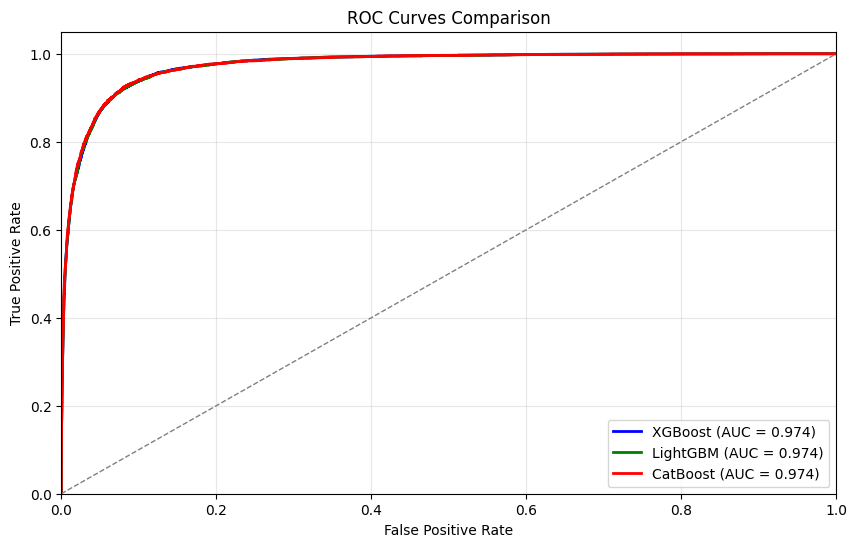

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# ----------------------------
# Compute ROC curves
# ----------------------------
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_gbm, tpr_gbm, _ = roc_curve(y_val, y_pred_gbm)
roc_auc_gbm = auc(fpr_gbm, tpr_gbm)

fpr_cat, tpr_cat, _ = roc_curve(y_val, y_pred_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

# ----------------------------
# Plot ROC curves
# ----------------------------
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot(fpr_gbm, tpr_gbm, color='green', lw=2, label=f'LightGBM (AUC = {roc_auc_gbm:.3f})')
plt.plot(fpr_cat, tpr_cat, color='red', lw=2, label=f'CatBoost (AUC = {roc_auc_cat:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

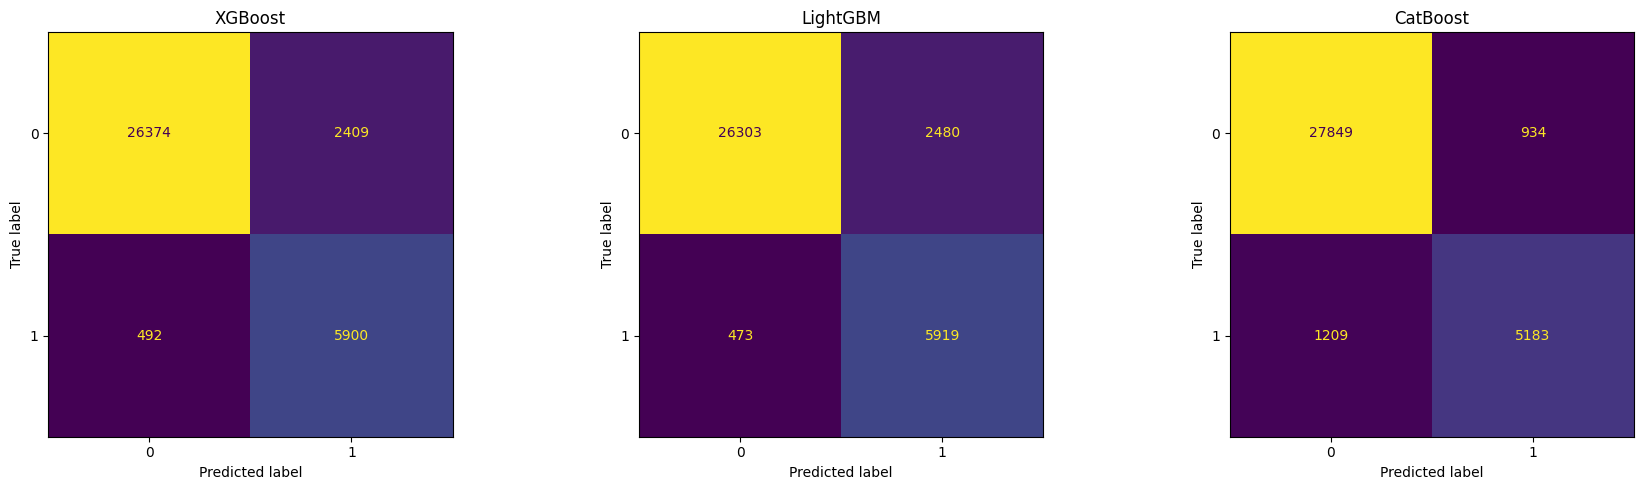

In [12]:
y_pred_xgb_cls = (y_pred_xgb > 0.5).astype(int)
y_pred_gbm_cls = (y_pred_gbm > 0.5).astype(int)
y_pred_cat_cls = (y_pred_cat > 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost CM
cm_xgb = confusion_matrix(y_val, y_pred_xgb_cls)
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot(ax=axes[0], colorbar=False)
axes[0].set_title("XGBoost")

# LightGBM CM
cm_gbm = confusion_matrix(y_val, y_pred_gbm_cls)
disp_gbm = ConfusionMatrixDisplay(cm_gbm)
disp_gbm.plot(ax=axes[1], colorbar=False)
axes[1].set_title("LightGBM")

# CatBoost CM
cm_cat = confusion_matrix(y_val, y_pred_cat_cls)
disp_cat = ConfusionMatrixDisplay(cm_cat)
disp_cat.plot(ax=axes[2], colorbar=False)
axes[2].set_title("CatBoost")

plt.tight_layout()
plt.show()

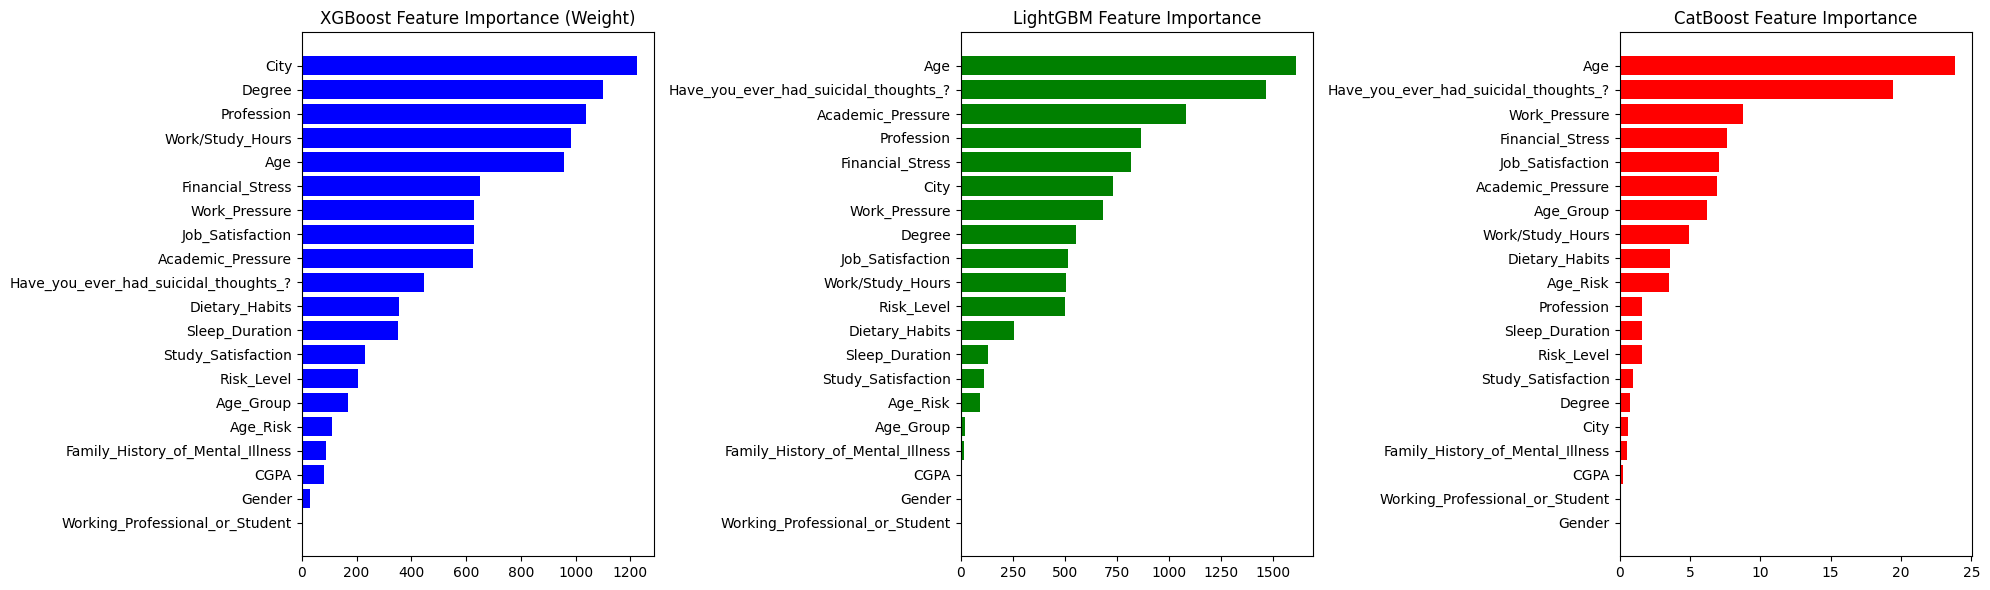

In [13]:
# ----------------------------
# XGBoost Feature Importance
# ----------------------------
xgb_importance = xgb_final.get_score(importance_type='weight')
xgb_importance = pd.Series(xgb_importance).sort_values(ascending=False)

# ----------------------------
# LightGBM Feature Importance
# ----------------------------
lgb_importance = pd.Series(lightgbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# ----------------------------
# CatBoost Feature Importance
# ----------------------------
cat_importance = pd.Series(cat_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False)

# ----------------------------
# Plot feature importance
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# XGBoost
axes[0].barh(xgb_importance.index[::-1], xgb_importance.values[::-1], color='blue')
axes[0].set_title('XGBoost Feature Importance (Weight)')

# LightGBM
axes[1].barh(lgb_importance.index[::-1], lgb_importance.values[::-1], color='green')
axes[1].set_title('LightGBM Feature Importance')

# CatBoost
axes[2].barh(cat_importance.index[::-1], cat_importance.values[::-1], color='red')
axes[2].set_title('CatBoost Feature Importance')

plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

# XGBoost
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb_cls))

# LightGBM
print("LightGBM Classification Report:")
print(classification_report(y_val, y_pred_gbm_cls))

# CatBoost
print("CatBoost Classification Report:")
print(classification_report(y_val, y_pred_cat_cls))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     28783
           1       0.71      0.92      0.80      6392

    accuracy                           0.92     35175
   macro avg       0.85      0.92      0.88     35175
weighted avg       0.93      0.92      0.92     35175

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.95     28783
           1       0.70      0.93      0.80      6392

    accuracy                           0.92     35175
   macro avg       0.84      0.92      0.87     35175
weighted avg       0.93      0.92      0.92     35175

CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     28783
           1       0.85      0.81      0.83      6392

    accuracy                           0.94     35175
   macro avg       0.90      0.89

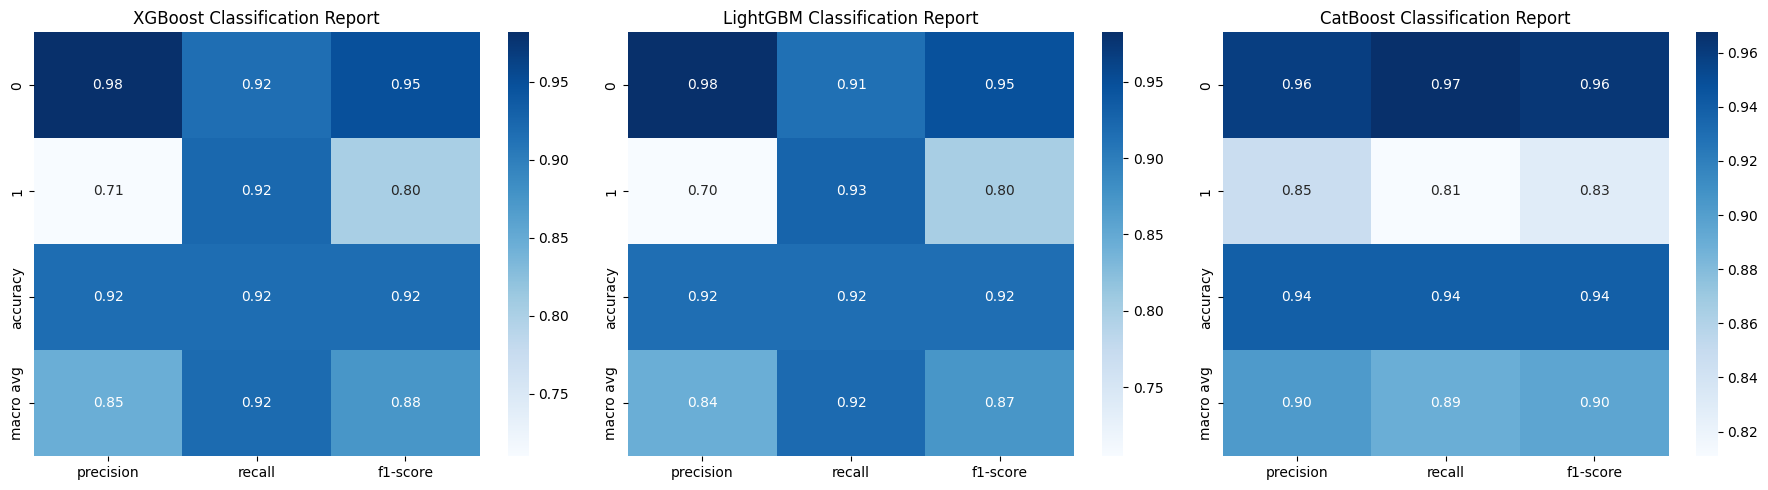

In [15]:
models = {
    "XGBoost": y_pred_xgb_cls,
    "LightGBM": y_pred_gbm_cls,
    "CatBoost": y_pred_cat_cls
}

plt.figure(figsize=(18,5))

for i, (name, y_pred) in enumerate(models.items(), 1):
    report = classification_report(y_val, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    plt.subplot(1, 3, i)
    sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"{name} Classification Report")

plt.tight_layout()
plt.show()

Based on the comparision between those 3 models
# => Catboost as my final model